# 05 · The platform spine, by hand — DGPs, estimators & the Monte-Carlo harness

This is the **architectural spine** of Lyra (LYRA §3–§5), built **from scratch** so you see every
mechanic before we lift any of it into `.py`. We implement, with the libraries directly:

1. a **DGP** we author (so we *know* the truth) — Level 0 (iid) then Level 1 (covariates → potential
   outcomes, a CATE surface, and a **confounding knob**);
2. three **estimators** by hand — difference-in-means, OLS adjustment, and **AIPW** (cross-fitted,
   doubly-robust) — writing out the score/influence function;
3. the **Monte-Carlo harness** — the raw loop `sample → estimate → compare-to-truth` that reports
   bias / coverage / power, and that will become the *promotion gate* for every future estimator;
4. the **robustness grid** — deliberately break assumptions and watch **OLS bias while AIPW survives**.

Nothing here imports our own helpers — it's all raw. Once we understand it, the *next* step is to
extract these functions into `lyra/` (the harden → promote stage). Learn first, productionize second.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.model_selection import KFold

import nbtools; nbtools.set_style()
from nbtools import BLUE, GREEN, PINK, ORANGE, GRAY
DIFF, OLS, AIPW = PINK, ORANGE, GREEN     # estimator colours

## 1. The idea — two mirror-image contracts, closed by a loop

Estimators **guess** the effect from observable data; a DGP **knows** the truth. Their symmetry is
the whole architecture:

$$\textsf{sim} \;\to\; \textsf{assign} \;\to\; \textsf{estimate} \;\to\;
  \textsf{compare to truth} \;\to\; \textsf{coverage / bias / power}.$$

We don't need classes yet — a **DGP is a function** `sample(n, seed) -> DataFrame` plus a known true
ATE, and an **estimator is a function** `estimate(df) -> (point, ci)`. Build the loop once and every
method we add later gets a *certified: yes/no* badge for free.

## 2. Author a DGP (so we know the truth)

### Level 0 — iid, randomized, constant effect
The simplest world: $Y = \mu + \tau\,T + \varepsilon$, with $T\sim\text{Bernoulli}(\tfrac12)$. The
**potential outcomes** are $Y(0)=\mu+\varepsilon$ and $Y(1)=\mu+\tau+\varepsilon$; the **ATE** is
$\tau$ exactly — *we set it*, so we can grade any estimator against it.

In [2]:
def simulate_l0(n, ate=2.0, mu=10.0, sigma=5.0, seed=0):
    rng = np.random.default_rng(seed)
    treat = (rng.random(n) < 0.5).astype(int)
    y = mu + ate * treat + rng.normal(0, sigma, n)
    return pd.DataFrame({"treat": treat, "y": y})

d0 = simulate_l0(2000, ate=2.0, seed=1)
print("L0 sample:", len(d0), "rows | naive diff-in-means =",
      round(d0[d0.treat == 1].y.mean() - d0[d0.treat == 0].y.mean(), 3), " (true ATE = 2.0)")
d0.head(3)

L0 sample: 2000 rows | naive diff-in-means = 2.061  (true ATE = 2.0)


,treat,y
0,0,5.005127
1,0,10.705426
2,1,19.876913


### Level 1 — covariates → potential outcomes, with a confounding knob

Now each unit has covariates $X\in\mathbb R^d$. We author the potential outcomes:
$$Y(0)=b(X)+\varepsilon,\qquad Y(1)=Y(0)+\tau,\qquad \text{(ATE }=\tau).$$
The **baseline** $b(X)$ can be linear or **nonlinear**. The **confounding knob** controls the
propensity $e(X)=P(T=1\mid X)$:
$$e(X)=\begin{cases}\tfrac12 & \text{(randomized — a clean experiment)}\\[2pt]
  \sigma\!\big(\kappa\cdot c(X)\big) & \text{(observational — selection on }X)\end{cases}$$
When $\kappa>0$, the *same* $X$ drives both who gets treated and the baseline — so treated and control
groups differ in $X$, and a naive comparison confuses the treatment with $b(X)$. **We author all of
it, so the true ATE is known no matter how nasty the confounding.**

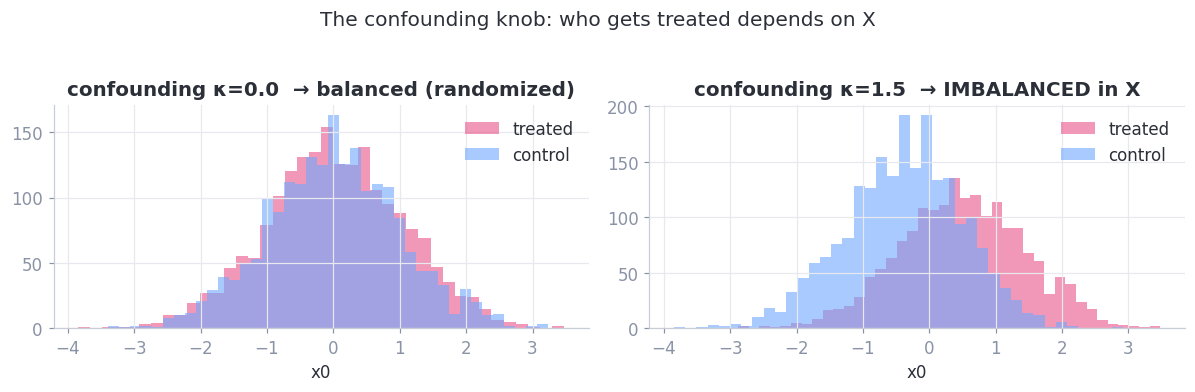

In [3]:
def baseline(X, nonlinear):
    if nonlinear:                      # genuinely curved in X — a linear model can't match it
        return 2.0 * np.sin(1.5 * X[:, 0]) + X[:, 1] ** 2 + 1.5 * X[:, 0] * X[:, 1]
    return 1.2 * X[:, 0] - 0.8 * X[:, 1] + 0.5 * X[:, 2]

def simulate_l1(n, ate=2.0, confounding=0.0, nonlinear=False, d=5, sigma=1.0, seed=0):
    rng = np.random.default_rng(seed)
    X = rng.normal(0, 1, (n, d))
    b = baseline(X, nonlinear)
    c = X[:, 0] + (X[:, 1] ** 2 - 1.0)                      # confounder signal (mean ~0)
    e = np.full(n, 0.5) if confounding == 0 else 1 / (1 + np.exp(-confounding * c))
    treat = (rng.random(n) < e).astype(int)
    y0 = b + rng.normal(0, sigma, n)                        # potential outcome under control
    y = y0 + ate * treat                                   # observed = Y(0) or Y(0)+ate
    df = pd.DataFrame(X, columns=[f"x{j}" for j in range(d)])
    df.insert(0, "y", y); df.insert(0, "treat", treat)
    return df

# show the confounding: treated vs control differ in X when kappa>0
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for k, a in zip([0.0, 1.5], ax):
    dd = simulate_l1(4000, confounding=k, nonlinear=True, seed=2)
    a.hist(dd[dd.treat == 1].x0, bins=40, alpha=.6, color=PINK, label="treated")
    a.hist(dd[dd.treat == 0].x0, bins=40, alpha=.6, color=BLUE, label="control")
    a.set_title(f"confounding κ={k}  → {'balanced (randomized)' if k==0 else 'IMBALANCED in X'}")
    a.set_xlabel("x0"); a.legend()
fig.suptitle("The confounding knob: who gets treated depends on X", y=1.04)
plt.tight_layout(); plt.show()

## 3. Three estimators, by hand

### 3a. Difference-in-means — $\hat\tau = \bar y_1 - \bar y_0$
Unbiased *only* under randomization (then $T\perp X$, so the groups are comparable). Welch CI for
unequal variances.

In [4]:
def est_diff(df):
    t = df.loc[df.treat == 1, "y"].to_numpy(); c = df.loc[df.treat == 0, "y"].to_numpy()
    point = t.mean() - c.mean()
    se = np.sqrt(t.var(ddof=1) / t.size + c.var(ddof=1) / c.size)        # Welch SE
    dof = (se**4) / ((t.var(ddof=1)/t.size)**2/(t.size-1) + (c.var(ddof=1)/c.size)**2/(c.size-1))
    h = stats.t.ppf(0.975, dof) * se
    return point, (point - h, point + h), se

### 3b. OLS adjustment — regress $y$ on treatment **and the covariates**
$y_i=\alpha+\tau\,T_i + X_i'\beta + u_i$. The linear $X'\beta$ soaks up *linear* confounding, so OLS
is unbiased when $b(X)$ is linear — but it **cannot** match a curved $b(X)$, leaving residual
confounding. We read the coefficient on `treat` with a heteroskedasticity-robust (HC1) SE.

In [5]:
def est_ols(df):
    xcols = [c for c in df.columns if c.startswith("x")]
    Xd = sm.add_constant(df[["treat", *xcols]].to_numpy(float))
    m = sm.OLS(df.y.to_numpy(float), Xd).fit(cov_type="HC1")
    b, se = m.params[1], m.bse[1]                                        # 0=const, 1=treat
    return b, (b - 1.96 * se, b + 1.96 * se), se

### 3c. AIPW — doubly-robust, cross-fitted (the one that survives)
Augmented IPW combines an **outcome model** $\hat\mu_w(X)=\mathbb E[Y\mid X,T=w]$ and the **propensity**
$\hat e(X)$ in the influence function
$$\psi_i=\underbrace{\hat\mu_1(X_i)-\hat\mu_0(X_i)}_{\text{regression}}
  +\underbrace{\tfrac{T_i}{\hat e(X_i)}\big(Y_i-\hat\mu_1(X_i)\big)
  -\tfrac{1-T_i}{1-\hat e(X_i)}\big(Y_i-\hat\mu_0(X_i)\big)}_{\text{IPW correction on the residuals}},
  \qquad \hat\tau=\tfrac1n\textstyle\sum_i\psi_i.$$
Two reasons it's robust: **double robustness** (consistent if *either* $\hat\mu$ or $\hat e$ is right)
and **Neyman orthogonality** (first-order errors in the nuisances cancel). We fit the nuisances with
flexible ML (gradient boosting) so they can match the *nonlinear* baseline, and **cross-fit** (fit on
other folds, predict out-of-fold) so the fit can't overfit its own residual. The SE is the standard
deviation of the influence values, $\widehat{\mathrm{se}}=\mathrm{sd}(\psi)/\sqrt n$.

In [6]:
def est_aipw(df, n_splits=4, clip=0.02, seed=0):
    xcols = [c for c in df.columns if c.startswith("x")]
    X = df[xcols].to_numpy(float); y = df.y.to_numpy(float); t = df.treat.to_numpy(int)
    n = len(df); mu1 = np.zeros(n); mu0 = np.zeros(n); e = np.full(n, 0.5)
    for tr, te in KFold(n_splits, shuffle=True, random_state=seed).split(X):
        for arm, mu in ((1, mu1), (0, mu0)):                            # outcome model per arm
            sel = tr[t[tr] == arm]
            g = HistGradientBoostingRegressor(max_depth=3, max_iter=150, learning_rate=0.1)
            g.fit(X[sel], y[sel]); mu[te] = g.predict(X[te])
        if 0 < t[tr].mean() < 1:                                        # propensity model
            cl = HistGradientBoostingClassifier(max_depth=3, max_iter=150, learning_rate=0.1)
            cl.fit(X[tr], t[tr]); e[te] = cl.predict_proba(X[te])[:, 1]
    e = np.clip(e, clip, 1 - clip)                                      # overlap trimming
    psi = mu1 - mu0 + t / e * (y - mu1) - (1 - t) / (1 - e) * (y - mu0)
    point = psi.mean(); se = psi.std(ddof=1) / np.sqrt(n)
    return point, (point - 1.96 * se, point + 1.96 * se), se

**One run, confounded + nonlinear world** — watch the three estimators diverge from the truth (2.0):

In [7]:
dC = simulate_l1(4000, ate=2.0, confounding=1.5, nonlinear=True, seed=3)
for name, fn, col in [("diff", est_diff, DIFF), ("ols ", est_ols, OLS), ("aipw", lambda d: est_aipw(d, seed=3), AIPW)]:
    p, (lo, hi), se = fn(dC)
    print(f"  {name}: {p:+.3f}  CI [{lo:+.3f}, {hi:+.3f}]  (bias {p-2.0:+.3f})")

  diff: +4.070  CI [+3.916, +4.224]  (bias +2.070)
  ols : +3.438  CI [+3.277, +3.598]  (bias +1.438)


  aipw: +2.176  CI [+1.913, +2.439]  (bias +0.176)


## 4. The Monte-Carlo harness — the raw loop

A single estimate is one draw; to *certify* an estimator we repeat the experiment $R$ times and look
at the **sampling behaviour**: bias (is it centred on truth?), **coverage** (do the 95% CIs contain
truth 95% of the time?), and the **reject rate** (= type-I error if the truth is 0, = power if not).
This loop is the platform's power engine *and* the gate a method must pass to be promoted.

In [8]:
def run_harness(estimate_fn, simulate_fn, R=200, n=2000, alpha=0.05, **dgp_kw):
    truth = dgp_kw.get("ate", 0.0)
    pts, cover, rej = [], [], []
    for r in range(R):
        df = simulate_fn(n, seed=1000 + r, **dgp_kw)
        p, (lo, hi), se = estimate_fn(df)
        pts.append(p); cover.append(lo <= truth <= hi); rej.append(not (lo <= 0 <= hi))
    pts = np.array(pts)
    return {"bias": pts.mean() - truth, "rmse": np.sqrt(((pts - truth) ** 2).mean()),
            "coverage": np.mean(cover), "reject_rate": np.mean(rej),
            "label": "type_I" if abs(truth) < 1e-9 else "power"}

# sanity on the easy world: diff-in-means should be unbiased with ~95% coverage and ~5% type-I
print("L0, diff, under H0 (ate=0):", {k: round(v, 3) for k, v in
      run_harness(est_diff, simulate_l0, R=400, n=1500, ate=0.0).items() if k != "label"})
print("L0, diff, under H1 (ate=2):", {k: round(v, 3) for k, v in
      run_harness(est_diff, simulate_l0, R=400, n=1500, ate=2.0).items() if k != "label"})

L0, diff, under H0 (ate=0): {'bias': 0.004, 'rmse': 0.267, 'coverage': 0.95, 'reject_rate': 0.05}


L0, diff, under H1 (ate=2): {'bias': 0.004, 'rmse': 0.267, 'coverage': 0.95, 'reject_rate': 1.0}


Coverage ≈ 0.95 and type-I ≈ 0.05 — the harness confirms diff-in-means is *correct* on the world
where its assumption (randomization) holds. That's the green light a method needs to be trusted.

### Power / MDE falls out of the same loop
Power *is* "simulate under H1, count rejections." So sample-sizing is not a separate module — it's the
harness swept over the true effect (here on L1, randomized).

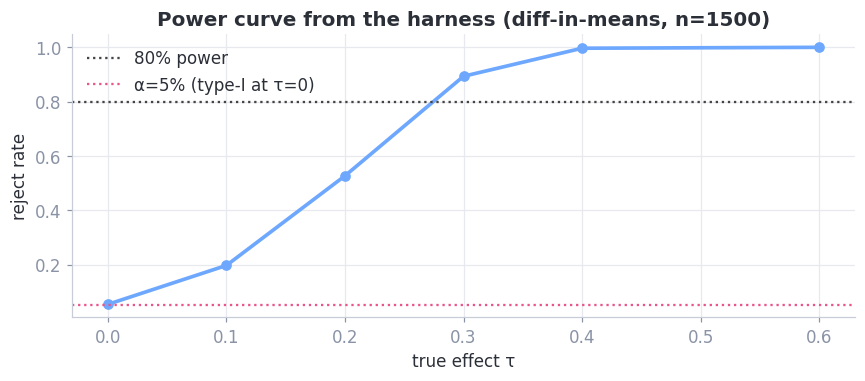

In [9]:
effects = [0.0, 0.1, 0.2, 0.3, 0.4, 0.6]
pw = [run_harness(est_diff, simulate_l1, R=300, n=1500, ate=tau, confounding=0.0)["reject_rate"]
      for tau in effects]
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(effects, pw, "-o", color=BLUE, lw=2.4)
ax.axhline(0.8, color="#444", ls=":", label="80% power"); ax.axhline(0.05, color=PINK, ls=":", label="α=5% (type-I at τ=0)")
ax.set_xlabel("true effect τ"); ax.set_ylabel("reject rate"); ax.set_title("Power curve from the harness (diff-in-means, n=1500)")
ax.legend(); plt.tight_layout(); plt.show()

## 5. The robustness grid — break assumptions, see who survives

The senior move (LYRA §6): if the DGP matches an estimator's assumptions it looks perfect and proves
nothing — you graded the exam you wrote. So we deliberately **violate** assumptions across four worlds
and chart bias + CI coverage for each estimator. The headline cell is **confounded + nonlinear**.

In [10]:
scenarios = {
    "randomized + linear":    dict(confounding=0.0, nonlinear=False),
    "randomized + nonlinear": dict(confounding=0.0, nonlinear=True),
    "confounded + linear":    dict(confounding=1.2, nonlinear=False),
    "confounded + nonlinear": dict(confounding=1.5, nonlinear=True),
}
ests = {"diff": est_diff, "ols": est_ols, "aipw": lambda d: est_aipw(d, seed=7)}
bias = pd.DataFrame(index=scenarios, columns=ests, dtype=float)
cov = pd.DataFrame(index=scenarios, columns=ests, dtype=float)
for scen, kw in scenarios.items():
    for en, fn in ests.items():
        rep = run_harness(fn, simulate_l1, R=50, n=1500, ate=2.0, **kw)
        bias.loc[scen, en] = rep["bias"]; cov.loc[scen, en] = rep["coverage"]
print("BIAS (truth ATE = 2.0):"); print(bias.round(3).to_string())
print("\nCI COVERAGE (target 0.95):"); print(cov.round(2).to_string())

BIAS (truth ATE = 2.0):
                         diff    ols   aipw
randomized + linear    -0.018 -0.003 -0.012
randomized + nonlinear -0.016 -0.005 -0.003
confounded + linear     0.928  0.004 -0.056
confounded + nonlinear  2.137  1.584  0.088

CI COVERAGE (target 0.95):
                        diff   ols  aipw
randomized + linear     0.94  0.96  0.96
randomized + nonlinear  0.98  0.96  0.98
confounded + linear     0.00  1.00  0.92
confounded + nonlinear  0.00  0.00  1.00


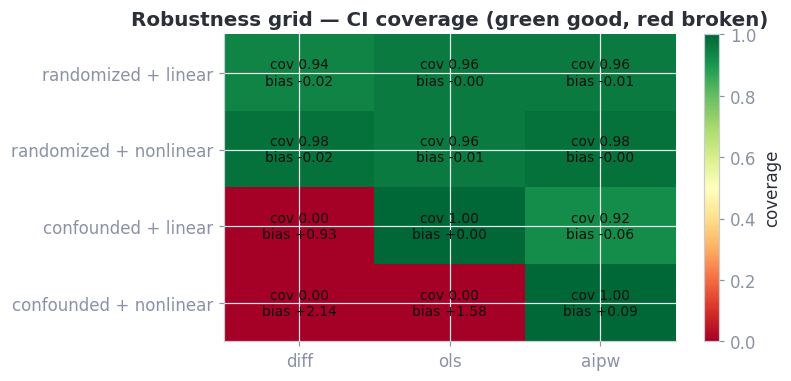

In [11]:
# the robustness grid as a heatmap, coloured by CI coverage (green=good, red=broken)
fig, ax = plt.subplots(figsize=(7.4, 3.6))
im = ax.imshow(cov.to_numpy(float), cmap="RdYlGn", vmin=0.0, vmax=1.0, aspect="auto")
ax.set_xticks(range(len(ests))); ax.set_xticklabels(ests.keys())
ax.set_yticks(range(len(scenarios))); ax.set_yticklabels(scenarios.keys())
for i in range(len(scenarios)):
    for j in range(len(ests)):
        ax.text(j, i, f"cov {cov.iloc[i,j]:.2f}\nbias {bias.iloc[i,j]:+.2f}",
                ha="center", va="center", fontsize=9, color="#111")
ax.set_title("Robustness grid — CI coverage (green good, red broken)")
fig.colorbar(im, ax=ax, label="coverage"); plt.tight_layout(); plt.show()

Read the bottom row — **confounded + nonlinear**:
- **diff** biases hard (ignores $X$ entirely) and its CI almost never covers truth.
- **ols** also biases — the *linear* adjustment can't match the curved $b(X)$, so residual confounding
  leaks into the treatment coefficient. *This is the demonstrated "OLS biases" point.*
- **aipw** stays ≈ unbiased with ≈ 0.95 coverage — flexible nuisances + double robustness absorb the
  nonlinear confounding. *This is "AIPW survives."*

(Top rows are the sanity checks: under randomization all three agree, because $T\perp X$.)

## 6. What we built, and the next step

By hand, from the libraries up: an **authored DGP** (we know the truth), three **estimators** (incl.
the AIPW influence function), the **Monte-Carlo harness** (bias / coverage / power), and the
**robustness grid**. We *understand* every line.

**Now we promote** (LYRA §10): lift these raw functions into `lyra/` — `dgp.py` (the fidelity ladder),
`estimators.py` (behind a small `Estimator` contract), and `harness.py` (the reusable certifier) — so
every future method (CATE learners, switchback, DiD…) is gated by this same harness against a known
truth. That extraction is the next session; the understanding came first.